In [42]:

import xarray as xr
import pandas as pd


import xarray as xr
import pandas as pd

ds_sat= xr.open_dataset('LGMR_data/ds_sat_flipped.nc')
df_pre= pd.read_csv(r"D:\VScode\Inso_LGMR\inso_data\pre.csv")
df_obl= pd.read_csv(r"D:\VScode\Inso_LGMR\inso_data\obl.csv")
ds_sat_ens= xr.open_dataset('LGMR_data/ds_sat_ens_flipped.nc')
df_pre.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     120 non-null    float64
 1   pre     120 non-null    float64
dtypes: float64(2)
memory usage: 2.0 KB


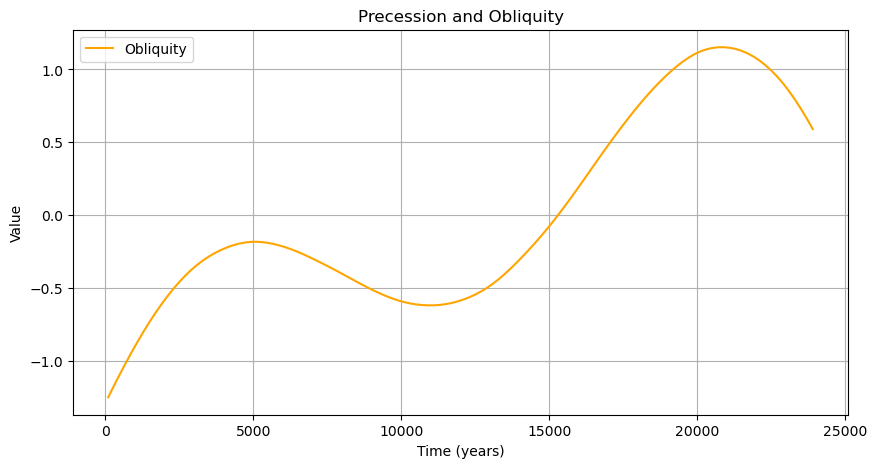

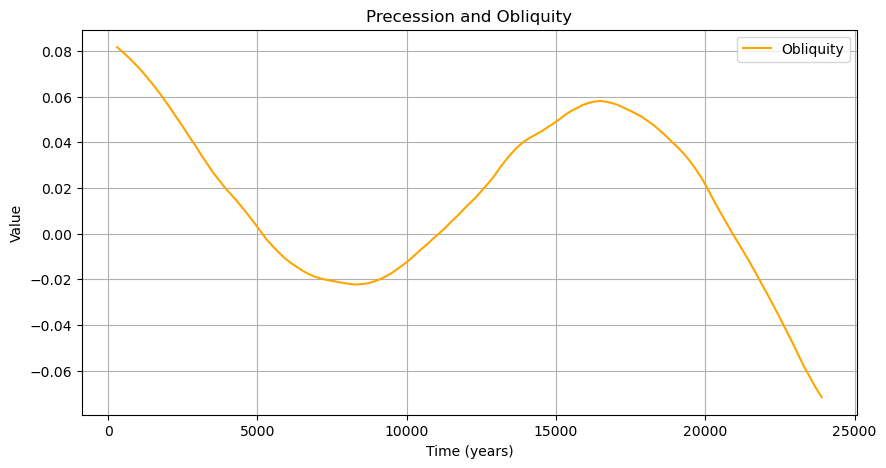

In [58]:
# plot df_pre and df_obl and plot pre+obl
import matplotlib.pyplot as plt
from scipy.stats import zscore
import numpy as np

plt.figure(figsize=(10, 5))
# plt.plot(df_pre['age'], df_pre['pre'], label='Precession', color='blue')
# plt.plot(df_obl['age'], df_obl['obl'], label='Obliquity', color='orange')
plt.plot(df_obl['age'], zscore(df_obl['obl'])+zscore(df_pre['pre']), label='Obliquity', color='orange')
plt.title('Precession and Obliquity')
plt.xlabel('Time (years)')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()

# create another figure and plot the diff of pre+obl
plt.figure(figsize=(10, 5))
plt.plot(df_obl['age'].iloc[1:], np.diff(zscore(df_obl['obl'])+zscore(df_pre['pre'])), label='Obliquity', color='orange')
plt.title('Precession and Obliquity')
plt.xlabel('Time (years)')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()


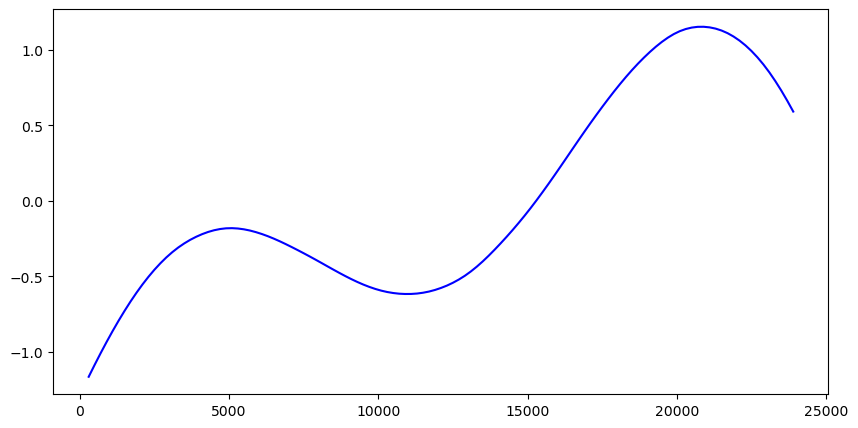

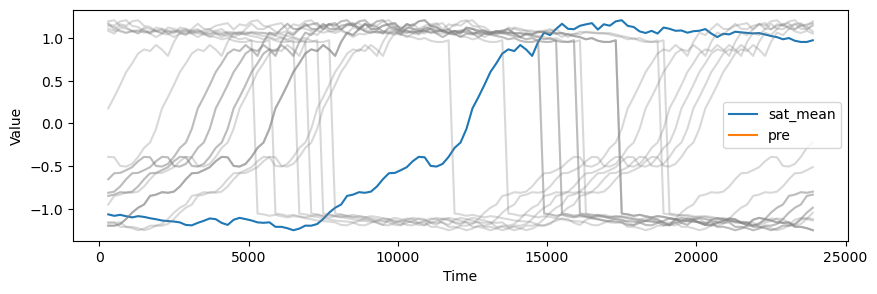

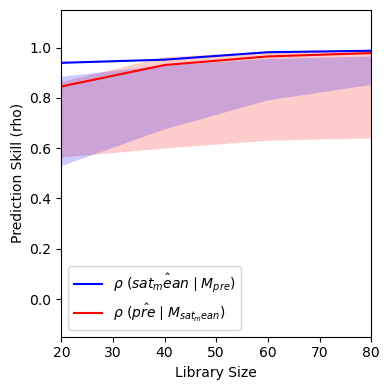

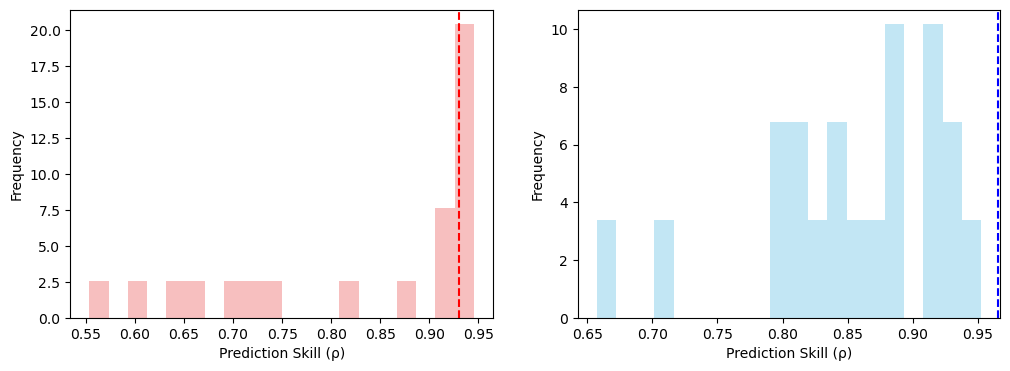

(False, True)


In [63]:
from toolbox import significant_test as st
import importlib
importlib.reload(st)

sat_mean = ds_sat['sat'].isel(lat=80).isel(lon=7).values 
# sat_mean = ds_sat['sat'].mean(dim=['lat', 'lon']).values
df_sat_mean = pd.DataFrame({'age': ds_sat['age'].values, 'sat_mean': sat_mean})

# # # calculate the direvative of the sat_mean column and crop the age to the same length as df_syn
# df_sat_mean['sat_mean'] = df_sat_mean['sat_mean'].diff()
# df_sat_mean = df_sat_mean.dropna()

df_syn=df_pre.copy()
df_syn['pre']=zscore(df_obl['obl'])+zscore(df_pre['pre'])
# crop the pre to the same length as df_sat_mean by drop the first row
df_syn = df_syn.iloc[1:]

# plot df_syn
plt.figure(figsize=(10, 5))
plt.plot(df_syn['age'], df_syn['pre'], label='Precession', color='blue')


ccm_out, ran_ccm_list,test_result = st.ccm_significance_test_v2(
    df_sd      = df_sat_mean,
    df_pre     = df_syn,
    E         = 5,
    tau       = 3,
    Tp =0,
    n_ran     = 20,
    libSizes  = "20 40 60 80",
    sample    = 20,
    showPlot  = True
)


print(test_result)

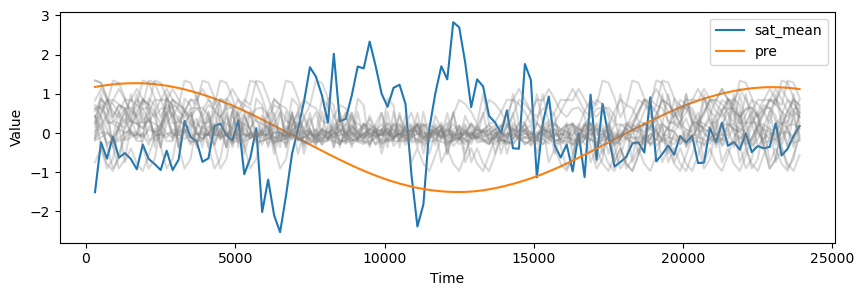

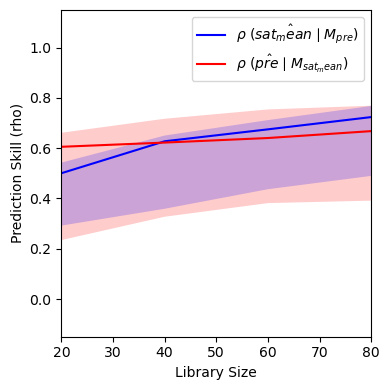

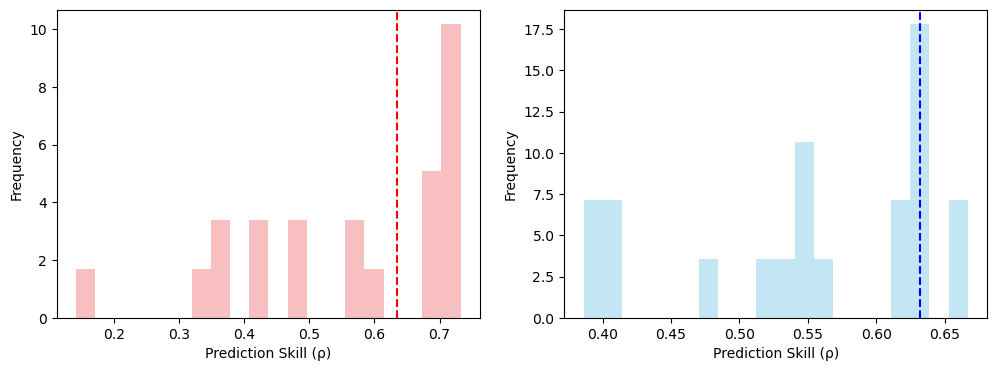

(False, False)


In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# Example sine function for fitting
def sine_func(t, A, omega, phase, offset):
    return A * np.sin(omega * t + phase) + offset

# Assuming df_pre contains columns "age" and "pre"
t = df_pre['age'].values
pre = df_pre['pre'].values

# Initial guesses for amplitude, frequency, phase, offset
guess = [np.std(pre), 2*np.pi/(t[-1]-t[0]), 0, np.mean(pre)]
params, _ = curve_fit(sine_func, t, pre, p0=guess)

# Remove the fitted sine (seasonal cycle) from the original signal:
pre_deseason = pre - sine_func(t, *params)
df_pre_copy = df_pre.copy()
df_pre_copy['pre'] = pre_deseason

# # plot df_pre and df_pre_copy
# import matplotlib.pyplot as plt
# plt.figure(figsize=(12, 6))
# plt.plot(df_pre['age'], df_pre['pre'], label='Original Precipitation')
# plt.plot(df_pre_copy['age'], df_pre_copy['pre'], label='Deseasonalized Precipitation')
# plt.plot(t, sine_func(t, *params), label='Fitted Sine Wave', linestyle='--')
# plt.xlabel('Age')
# plt.ylabel('Precipitation')
# plt.title('Deseasonalization of Precipitation Data')
# plt.legend()
# plt.grid()
# plt.show()

# plt.figure(figsize=(12, 6))
# plt.plot(df_pre_copy['age'], df_pre_copy['pre'], label='Deseasonalized Precipitation')


from toolbox import significant_test as st
import importlib
importlib.reload(st)

sat_mean = ds_sat['sat'].isel(lat=80).isel(lon=0).values 
# sat_mean = ds_sat['sat'].mean(dim=['lat', 'lon']).values
df_sat_mean = pd.DataFrame({'age': ds_sat['age'].values, 'sat_mean': sat_mean})

# # # calculate the direvative of the sat_mean column and crop the age to the same length as df_syn
# df_sat_mean['sat_mean'] = df_sat_mean['sat_mean'].diff()
# df_sat_mean = df_sat_mean.dropna()

df_pre_short=df_pre.copy()
# crop the pre to the same length as df_sat_mean by drop the first row
df_pre_short = df_pre_short.iloc[1:]


ccm_out, ran_ccm_list,test_result = st.ccm_significance_test_v2(
    df_sd      = df_sat_mean,
    df_pre     = df_pre_short,
    E         = 5,
    tau       = 3,
    Tp =0,
    n_ran     = 20,
    libSizes  = "20 40 60 80",
    sample    = 20,
    showPlot  = True
)


print(test_result)

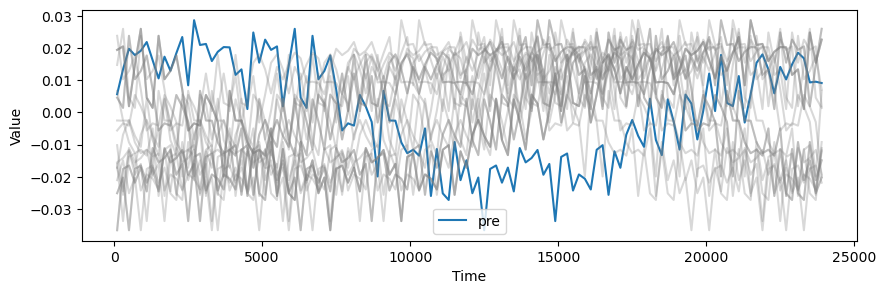

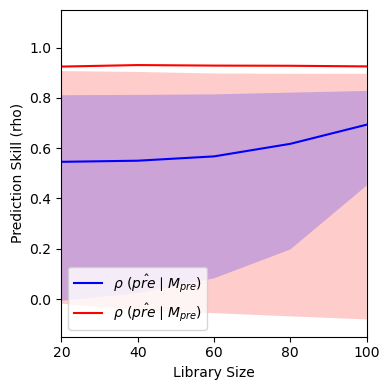

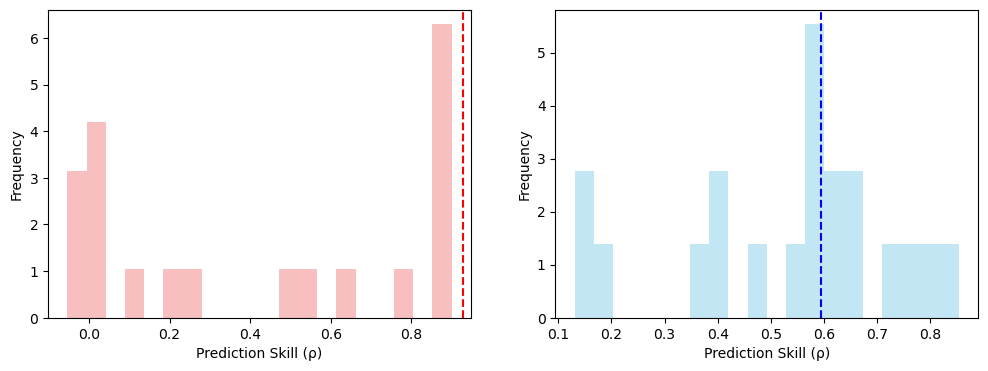

(True, False)


In [13]:
import numpy as np
import pandas as pd

# Parameters
lag = 5  # number of steps to shift the "pre" data
noise_level = 0.5  # noise level as a fraction of the std of pre

# Compute noise standard deviation
noise_std = noise_level * df_pre['pre'].std()

shifted_pre = np.roll(df_pre['pre'].values, lag)

# Add Gaussian noise
noisy_pre = shifted_pre + np.random.normal(0, noise_std, size=len(shifted_pre))

# Create the new DataFrame
df_syn = pd.DataFrame({
    'age': df_pre['age'],
    'pre': noisy_pre
})


from toolbox import significant_test as st
import importlib
importlib.reload(st)

ccm_out, ran_ccm_list,test_result = st.ccm_significance_test_v2(
    df_sd      = df_syn,
    df_pre     = df_pre,
    E         = 2,
    tau       = 1,
    Tp =-5,
    n_ran     = 20,
    libSizes  = "20 40 60 80 100",
    sample    = 20,
    showPlot  = True
)


print(test_result)

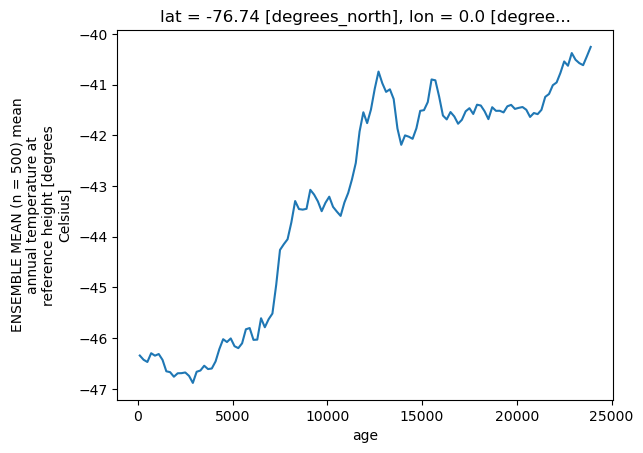

In [6]:
ds_sat['sat'].isel(lat=7, lon=0).plot()

# Calculate mean sat and fit it with a sin function

In [140]:
import plotly.graph_objects as go
import numpy as np
from scipy.optimize import curve_fit
import xarray as xr
import pandas as pd

# Calculate the spatial mean of SAT across latitude and longitude
sat_mean = ds_sat['sat'].mean(dim=['lat', 'lon']).values
age = ds_sat['age'].values

# Define sine fitting function
def sin_func(x, A, omega, phase, offset):
    return A * np.sin(omega * x + phase) + offset

# Initial guess for the parameters
initial_guess = [np.std(sat_mean), 2 * np.pi / np.ptp(age), 0, np.mean(sat_mean)]

# Fit sine curve to the data
params, _ = curve_fit(sin_func, age, sat_mean, p0=initial_guess)

# Generate fitted values
sat_fit = sin_func(age, *params)

# Plot using Plotly
fig = go.Figure()

fig.add_trace(go.Scatter(x=age, y=sat_mean,
                         mode='lines+markers',
                         name='Mean SAT',
                         line=dict(color='blue')))

fig.add_trace(go.Scatter(x=age, y=sat_fit,
                         mode='lines',
                         name='Sine Fit',
                         line=dict(color='red', dash='dash')))

fig.update_layout(
    title='Mean SAT and Sine Fit',
    xaxis_title='Age',
    yaxis_title='Mean SAT (°C)',
    width=900,
    height=500
)

fig.show()

# Combine results into a DataFrame
df_fit = pd.DataFrame({'age': age, 'sat_fit': sat_fit})


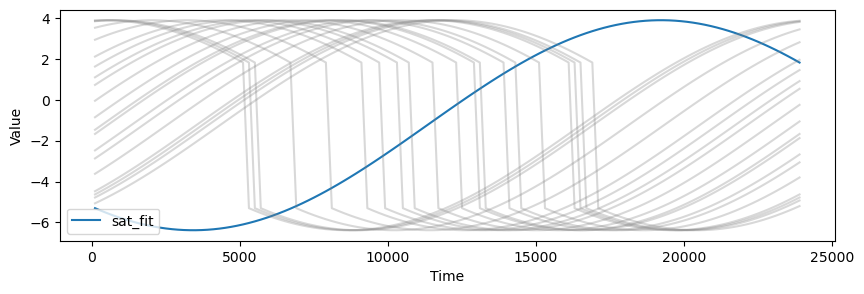

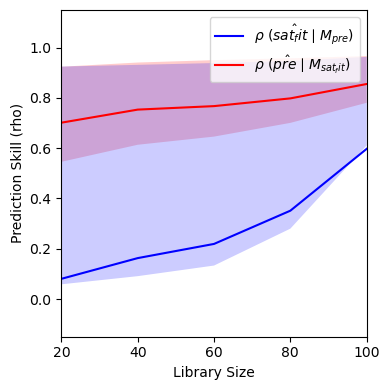

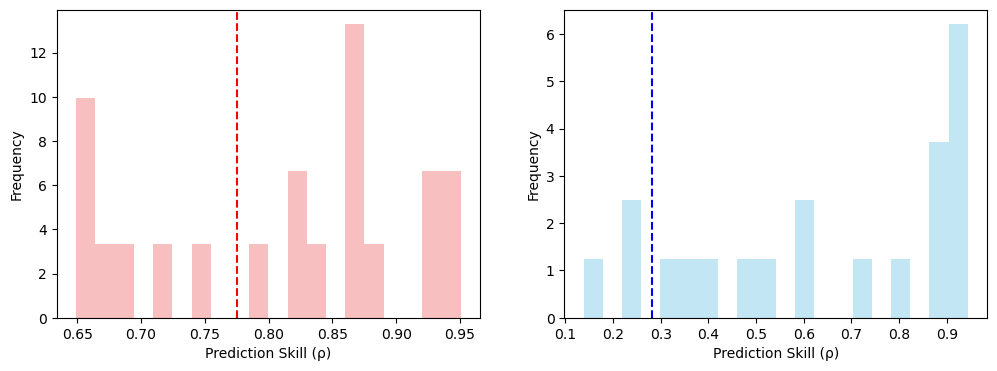

(False, False)


In [13]:
from toolbox import significant_test as st
import importlib
importlib.reload(st)

ccm_out, ran_ccm_list,test_result = st.ccm_significance_test_v2(
    df_sd      = df_fit,
    df_pre     = df_pre,
    E         = 2,
    tau       = 1,
    Tp =-5,
    n_ran     = 20,
    libSizes  = "20 40 60 80 100",
    sample    = 20,
    showPlot  = True
)


print(test_result)

# Fit the data using lines

In [20]:
import numpy as np
import xarray as xr
import pandas as pd
import plotly.graph_objects as go
from scipy.optimize import curve_fit

# Read the data
ds_sat = xr.open_dataset('LGMR_data/ds_sat_flipped.nc')
# Calculate the spatial mean of SAT across latitude and longitude
sat_mean = ds_sat['sat'].mean(dim=['lat', 'lon']).values
age = ds_sat['age'].values

# Define the piecewise linear function with two break points.
# We reparameterize the second breakpoint as x_break2 = x_break1 + delta, ensuring delta > 0.
def piecewise_linear(x, b, m1, m2, m3, x_break1, delta):
    x_break2 = x_break1 + delta
    return np.piecewise(x,
                        [x < x_break1,
                         (x >= x_break1) & (x < x_break2),
                         x >= x_break2],
                        [lambda x: m1 * x + b,
                         lambda x: m2 * x + (m1 * x_break1 + b - m2 * x_break1),
                         lambda x: m3 * x + (m2 * delta + m1 * x_break1 + b - m3 * (x_break1 + delta))])

# Provide initial guesses for the parameters.
# b: intercept for the first segment, m1: slope of first segment, m2: slope of second, m3: slope of third.
# x_break1 is initially set to roughly one-third of the age range, and x_break2 (via delta) is set to roughly two-thirds.
b0 = sat_mean[0]
m1_0 = (sat_mean[1] - sat_mean[0]) / (age[1] - age[0])
m3_0 = (sat_mean[-1] - sat_mean[-2]) / (age[-1] - age[-2])
m2_0 = (m1_0 + m3_0) / 2
x_break1_0 = age[len(age) // 3]
x_break2_0 = age[2 * len(age) // 3]
delta0 = x_break2_0 - x_break1_0

initial_guess = [b0, m1_0, m2_0, m3_0, x_break1_0, delta0]

# Set bounds.
# We require delta > 0 and x_break1 within the age range.
bounds_lower = [-np.inf, -np.inf, -np.inf, -np.inf, age[0], 1e-6]
bounds_upper = [np.inf, np.inf, np.inf, np.inf, age[-1], age[-1] - age[0]]

# Fit the piecewise linear model to the data.
params, _ = curve_fit(piecewise_linear, age, sat_mean, p0=initial_guess, bounds=(bounds_lower, bounds_upper))

# Generate fitted values using the obtained parameters.
sat_fit_piecewise = piecewise_linear(age, *params)

# Plot the original mean SAT and the piecewise linear fit using Plotly.
fig = go.Figure()

fig.add_trace(go.Scatter(x=age, y=sat_mean,
                         mode='lines+markers',
                         name='Mean SAT',
                         line=dict(color='blue')))

fig.add_trace(go.Scatter(x=age, y=sat_fit_piecewise,
                         mode='lines',
                         name='Piecewise Linear Fit',
                         line=dict(color='red', dash='dash')))

fig.update_layout(
    title='Mean SAT with Piecewise Linear Fit',
    xaxis_title='Age',
    yaxis_title='Mean SAT (°C)',
    width=900,
    height=500
)

fig.show()

# Combine the fitted values into a DataFrame if needed.
df_fit = pd.DataFrame({'age': age, 'sat_fit': sat_fit_piecewise})


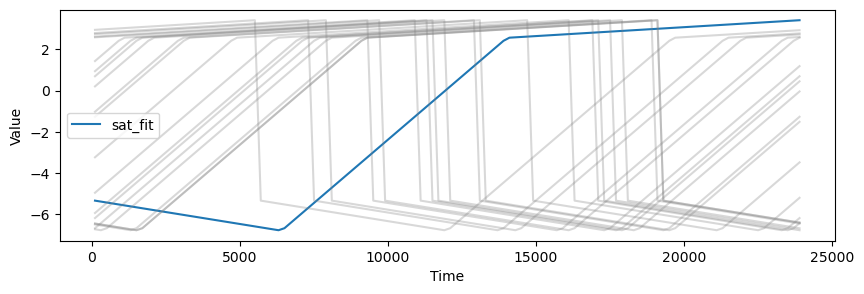

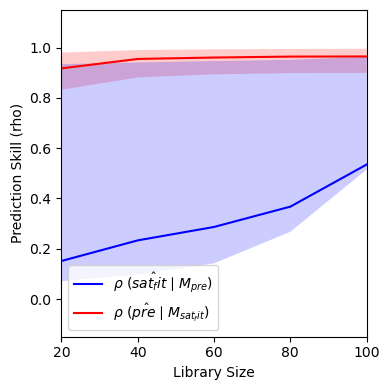

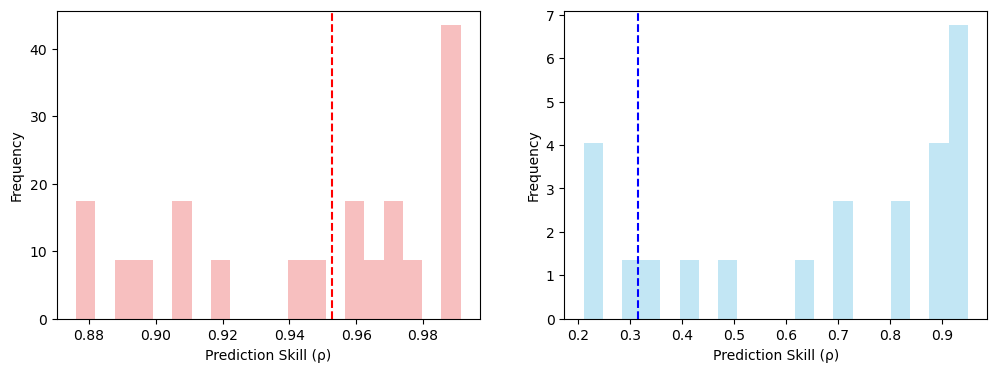

(False, False)


In [55]:
from toolbox import significant_test as st
import importlib
importlib.reload(st)

ccm_out, ran_ccm_list,test_result = st.ccm_significance_test_v2(
    df_sd      = df_fit,
    df_pre     = df_pre,
    E         = 2,
    tau       = 1,
    Tp =0,
    n_ran     = 20,
    libSizes  = "20 40 60 80 100",
    sample    = 20,
    showPlot  = True
)


print(test_result)

In [141]:
import numpy as np

def generate_synthetic_data(age, trend, pre, SNR=1.0, lag=0, causal_type='linear', causal_strength=1.0, random_seed=None, if_plot=False):
    """
    Generate synthetic data that consists of:
      - A trend component (e.g., your piecewise linear fit).
      - A causal component based on a precession (pre) series (with a given lag).
      - White noise, whose level is controlled by the SNR.

    Parameters:
    -----------
    age : array-like
        The independent variable (e.g., time or age) for the data.
    trend : array-like
        The trend component of the synthetic data.
    pre : array-like
        The precession data series. Must be defined on the same grid as age.
    SNR : float, optional
        Signal-to-noise ratio, defined as (std(trend) / noise_std). Default is 1.0.
    lag : float, optional
        The lag to apply to the pre data. The causal component uses pre(t - lag).
    causal_type : {'linear', 'nonlinear'}, optional
        Type of causal relationship to use. For 'linear': causal = causal_strength * pre.
        For 'nonlinear': causal = causal_strength * tanh(pre).
    causal_strength : float, optional
        Coefficient scaling the effect of pre.
    random_seed : int, optional
        Random seed for reproducibility.

    Returns:
    --------
    synthetic_data : np.ndarray
        The generated synthetic data with two columns: age and synthetic data.
    """
    
    # Optionally set the random seed for reproducibility
    if random_seed is not None:
        np.random.seed(random_seed)
    
    # normalize the trend using z-score
    trend = (trend - np.mean(trend)) / np.std(trend)
    # Normalize the pre data using z-score
    pre = (pre - np.mean(pre)) / np.std(pre)


    # Calculate the white noise sigma using SNR.
    # Here, SNR is defined as (std(trend)/sigma_noise)
    sigma_noise = np.std(trend) / SNR

    # if lag>0 shift pre rightward, if lag<0 shift pre leftward to create the pre_lagged
    # This is done by using np.roll, which rolls the array elements.
    # check if lag is int
    if isinstance(lag, int):
        pre_lagged = pre.copy()
        if lag > 0:
            pre_lagged = np.roll(pre_lagged, lag)
        elif lag < 0:
            pre_lagged = np.roll(pre_lagged, lag)
    else:
        raise ValueError("Lag must be an integer.")

    
    # Compute the causal part from pre depending on the chosen type.
    if causal_type == 'linear':
        causal_part = causal_strength * pre_lagged
    elif causal_type == 'nonlinear':
        # For nonlinear, an example nonlinear mapping is used (here: hyperbolic tangent).
        causal_part = causal_strength * np.tanh(pre_lagged)
        # causal_part = causal_strength * pre_lagged*pre_lagged  # Example of a nonlinear transformation (squared)
    else:
        raise ValueError("Unsupported causal_type. Please use 'linear' or 'nonlinear'.")
    
    # Generate white noise with the computed sigma.
    noise = np.random.normal(0, sigma_noise, size=len(age))

    # if if_plot, plot the comparison between pre and causal_part
    if if_plot:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(12, 6))
        plt.plot(age, pre, label='Precession', color='blue', alpha=0.5)
        plt.plot(age, causal_part, label='Causal Part', color='orange', alpha=0.5)
        plt.title('Precession and Causal Part')
        plt.xlabel('Age')
        plt.ylabel('Value')
        plt.legend()
        plt.show()
    
    # The synthetic data is the sum of the trend, the causal part, and the noise.
    synthetic_data = trend + causal_part + noise
    
    # Return a datafrome containing the age and synthetic data.
    df_synthetic_data = pd.DataFrame({'age': age, 'syn': synthetic_data})

    return df_synthetic_data


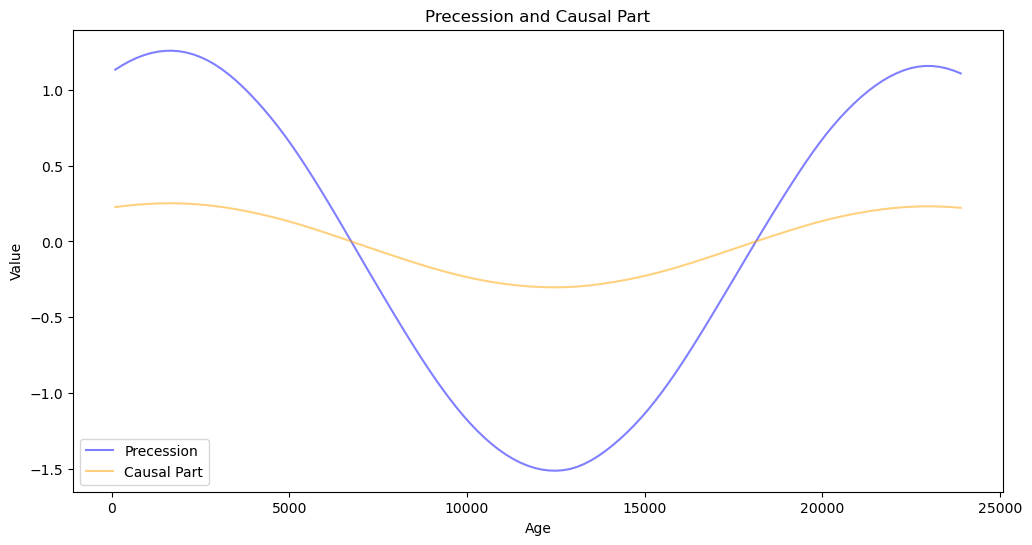

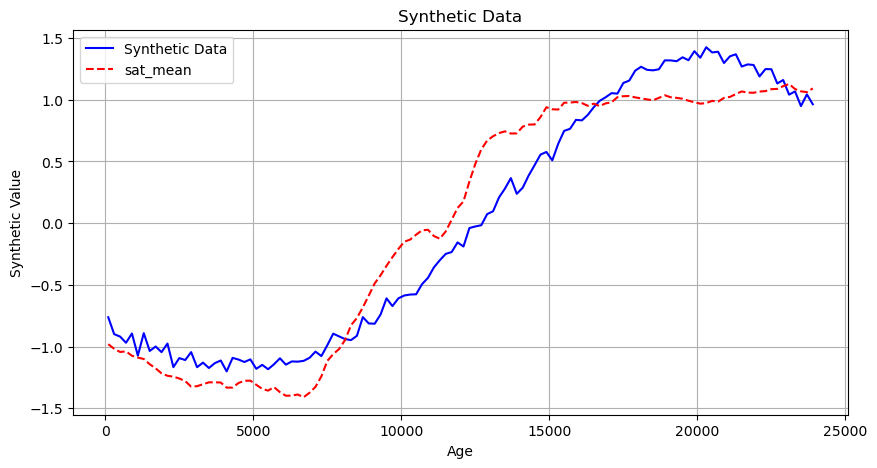

In [142]:

df_syn = generate_synthetic_data(df_fit['age'], df_fit['sat_fit'].values, df_pre['pre'].values, SNR=20.0, lag=0, causal_type='linear', causal_strength=0.2, random_seed=1, if_plot=True)

# plot the synthetic data using plt
import matplotlib.pyplot as plt
from scipy.stats import zscore

plt.figure(figsize=(10, 5))
plt.plot(df_syn['age'], df_syn['syn'], label='Synthetic Data', color='blue')
# plot sat mean
sat_mean = ds_sat['sat'].mean(dim=['lat', 'lon']).values
plt.plot(ds_sat['age'], zscore(sat_mean), label='sat_mean', color='red', linestyle='--')
plt.title('Synthetic Data')
plt.xlabel('Age')
plt.ylabel('Synthetic Value')
plt.legend()
plt.grid()
plt.show()

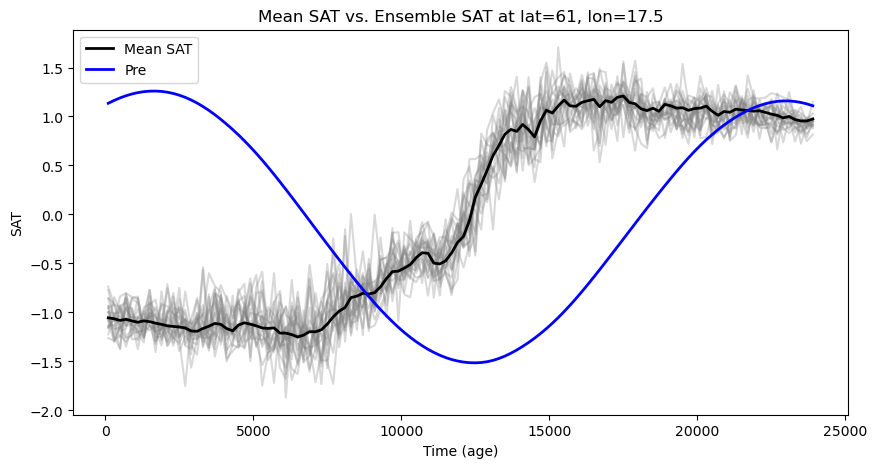

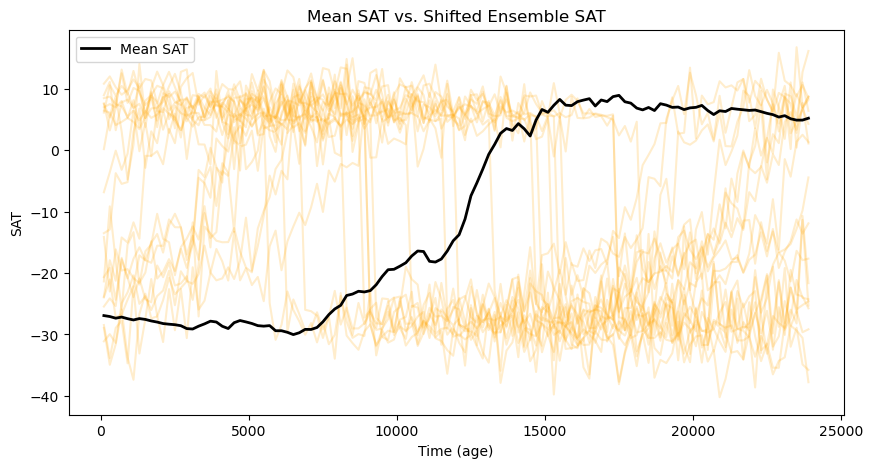

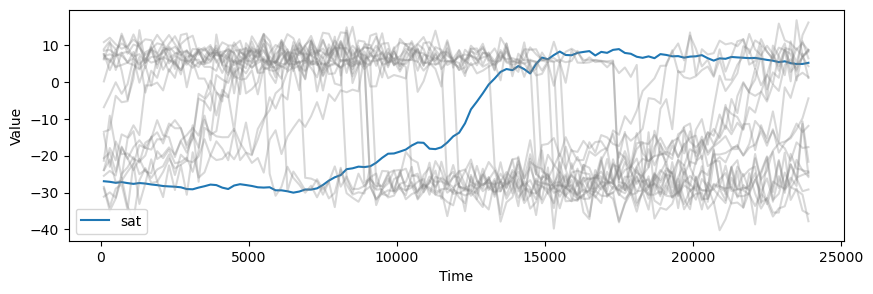

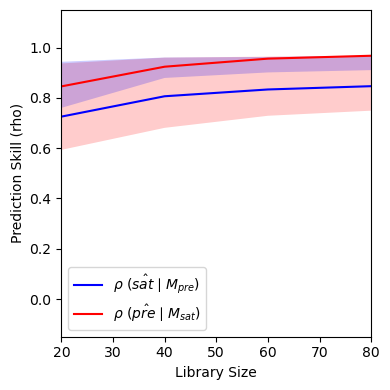

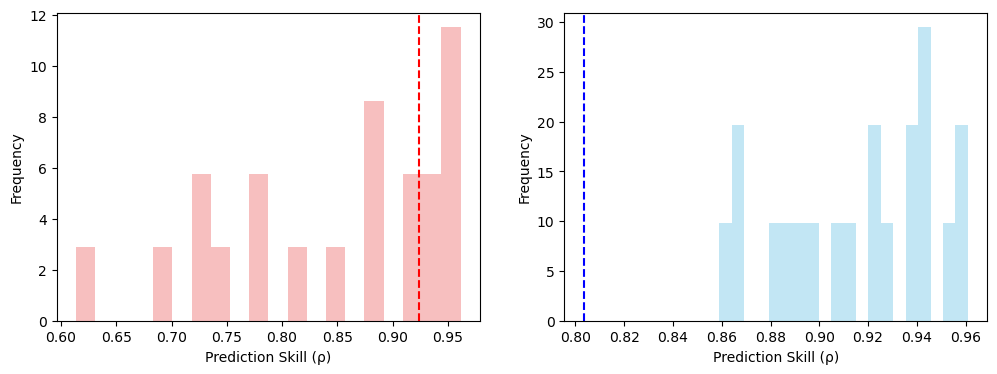

(False, False)


In [137]:
from toolbox import significant_test as st
import importlib
importlib.reload(st)




ccm_out, ran_ccm_list,test_result = st.ccm_significance_test_v1(
ds_sat=ds_sat, df_pre=df_pre, ds_sat_ens=ds_sat_ens, lat_idx=80, lon_idx=7,
    E         = 5,
    tau       = 3,
    Tp =0,
    n_ran     = 20,
    libSizes  = "20 40 60 80",
    sample    = 20,
    showPlot  = True
)


print(test_result)

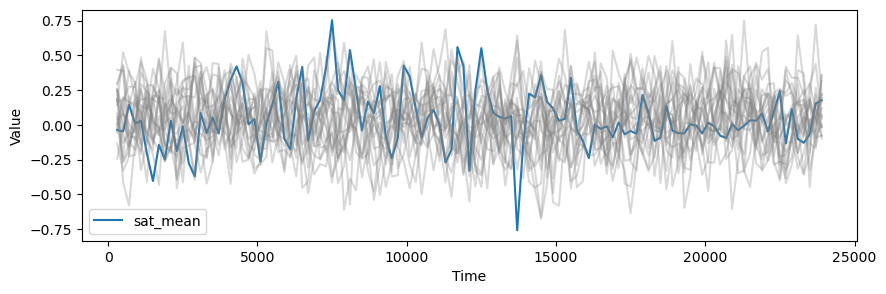

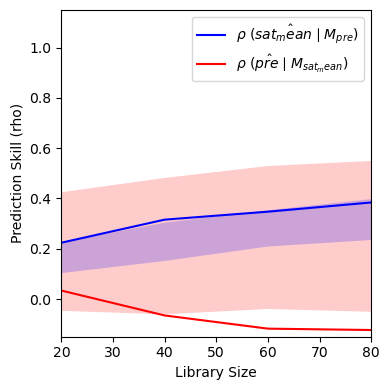

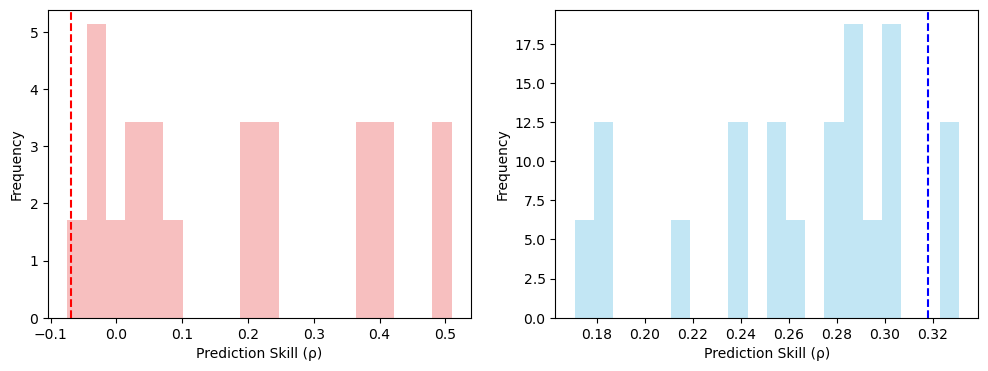

(False, False)


In [127]:
from toolbox import significant_test as st
import importlib
importlib.reload(st)

sat_mean = ds_sat['sat'].isel(lat=20).isel(lon=8).values 
# sat_mean = ds_sat['sat'].mean(dim=['lat', 'lon']).values
df_sat_mean = pd.DataFrame({'age': ds_sat['age'].values, 'sat_mean': sat_mean})

# # # calculate the direvative of the sat_mean column and crop the age to the same length as df_syn
df_sat_mean['sat_mean'] = df_sat_mean['sat_mean'].diff()
df_sat_mean = df_sat_mean.dropna()

df_pre_short=df_pre.copy()
# crop the pre to the same length as df_sat_mean by drop the first row
df_pre_short = df_pre_short.iloc[1:]


ccm_out, ran_ccm_list,test_result = st.ccm_significance_test_v3(
    df_sd      = df_sat_mean,
    df_pre     = df_pre_short,
    E         = 5,
    tau       = 3,
    Tp =0,
    n_ran     = 20,
    libSizes  = "20 40 60 80",
    sample    = 20,
    showPlot  = True
)


print(test_result)

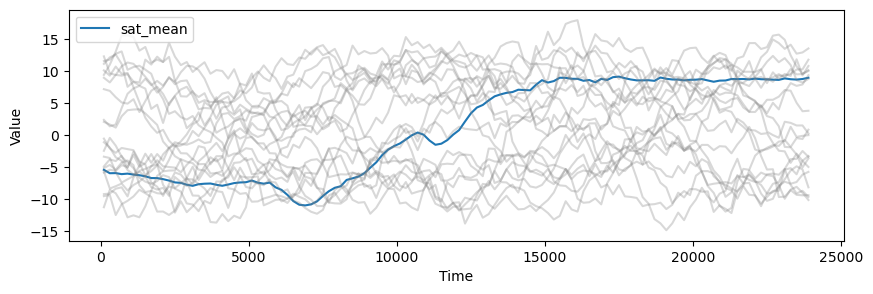

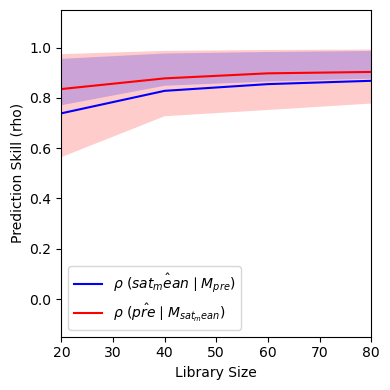

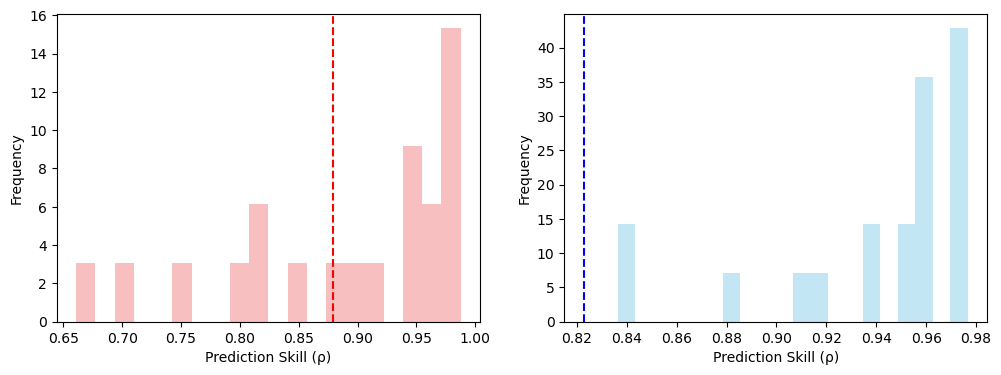

(False, False)


In [144]:
from toolbox import significant_test as st
import importlib
importlib.reload(st)

sat_mean = ds_sat['sat'].isel(lat=80).isel(lon=0).values 
# sat_mean = ds_sat['sat'].mean(dim=['lat', 'lon']).values
df_sat_mean = pd.DataFrame({'age': ds_sat['age'].values, 'sat_mean': sat_mean})

# # calculate the direvative of the sat_mean column and crop the age to the same length as df_syn
# df_sat_mean['sat_mean'] = df_sat_mean['sat_mean'].diff()
# df_sat_mean = df_sat_mean.dropna()

# df_pre_short=df_pre.copy()
# # crop the pre to the same length as df_sat_mean by drop the first row
# df_pre_short = df_pre_short.iloc[1:]


ccm_out, ran_ccm_list,test_result = st.ccm_significance_test_v3(
    df_sd      = df_sat_mean,
    df_pre     = df_pre,
    E         = 5,
    tau       = 3,
    Tp =0,
    n_ran     = 20,
    libSizes  = "20 40 60 80",
    sample    = 20,
    showPlot  = True
)


print(test_result)

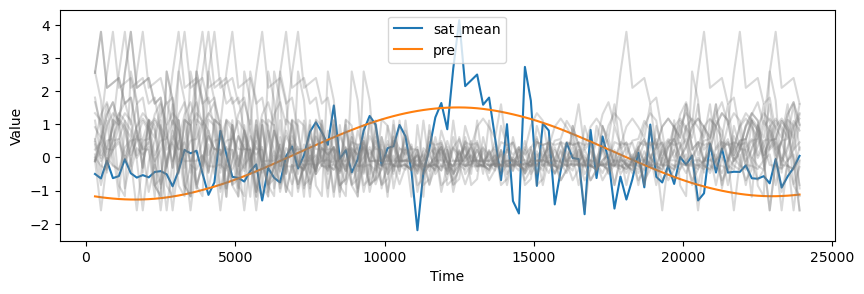

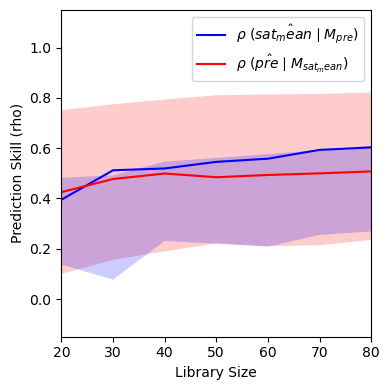

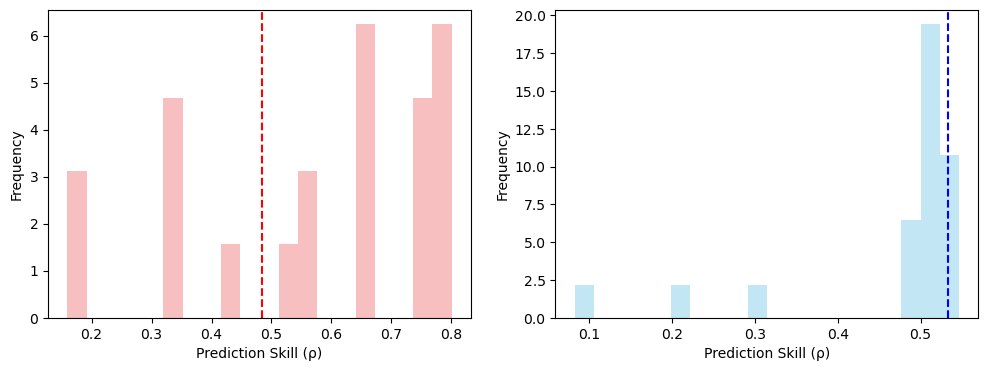

(False, False)


In [39]:
from toolbox import significant_test as st
import importlib
importlib.reload(st)

sat_mean = ds_sat['sat'].isel(lat=80).isel(lon=7).values 
# sat_mean = ds_sat['sat'].mean(dim=['lat', 'lon']).values
df_sat_mean = pd.DataFrame({'age': ds_sat['age'].values, 'sat_mean': sat_mean})

# # # calculate the direvative of the sat_mean column and crop the age to the same length as df_syn
df_sat_mean['sat_mean'] = df_sat_mean['sat_mean'].diff()
df_sat_mean = df_sat_mean.dropna()


df_pre['pre']=df_pre['pre']*-1
df_pre_short=df_pre.copy()
# crop the pre to the same length as df_sat_mean by drop the first row
df_pre_short = df_pre_short.iloc[1:]


ccm_out, ran_ccm_list,test_result = st.ccm_significance_test_v2(
    df_sd      = df_sat_mean,
    df_pre     = df_pre_short,
    E         = 5,
    tau       = 3,
    Tp =-8,
    n_ran     = 20,
    libSizes  = "20 30 40 50 60 70 80",
    sample    = 10,
    showPlot  = True
)


print(test_result)

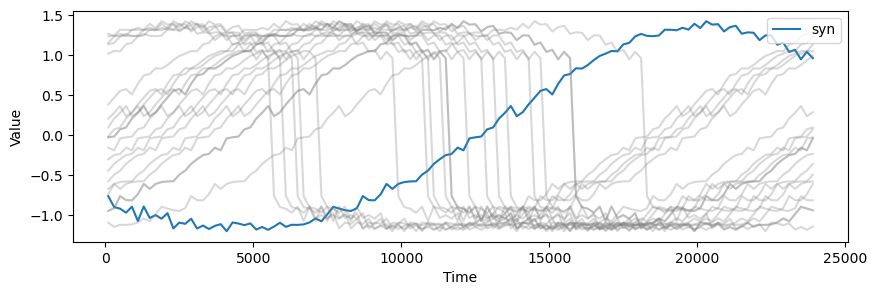

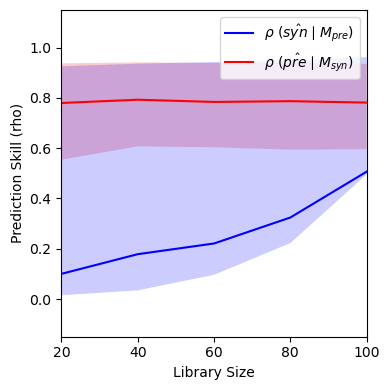

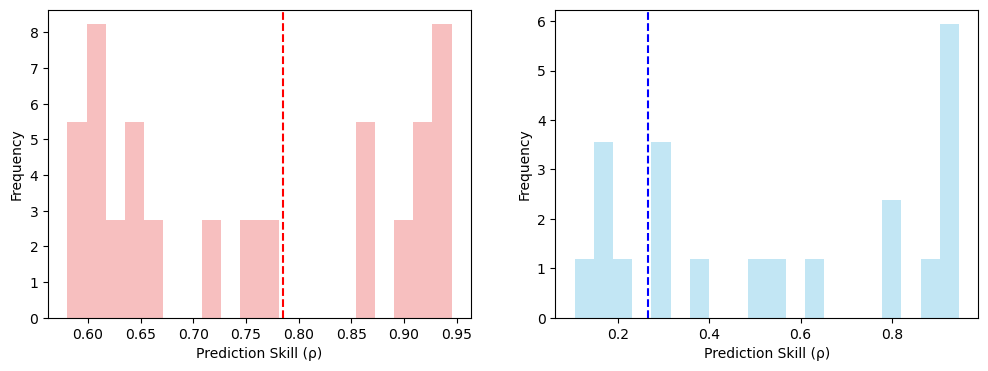

(False, False)


In [143]:
from toolbox import significant_test as st
import importlib
importlib.reload(st)

ccm_out, ran_ccm_list,test_result = st.ccm_significance_test_v2(
    df_sd      = df_syn,
    df_pre     = df_pre,
    E         = 2,
    tau       = 1,
    Tp =0,
    n_ran     = 20,
    libSizes  = "20 40 60 80 100",
    sample    = 20,
    showPlot  = True
)


print(test_result)